In [1]:
import sqlite3
import nfl_data_py as nfl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Connect to your "filing cabinet"
conn = sqlite3.connect('nfl_data.db')


In [2]:

query = """
SELECT
    play_type,
    COUNT(*) as total_plays,
    AVG(epa) as avg_epa,
    AVG(yards_gained) as avg_yards
FROM pbp_data
WHERE posteam = 'IND'
    AND season = 2025
    AND down IN (1,2)
    AND play_type IN ('run','pass')
GROUP BY play_type
"""

df_colts = pd.read_sql_query(query, conn)
print("Colts Early Down Efficiency (2025):")
print(df_colts)


Colts Early Down Efficiency (2025):
  play_type  total_plays   avg_epa  avg_yards
0      pass          423  0.043757   6.520095
1       run          361  0.051760   4.775623


In [3]:

    query = """
    SELECT
        CASE
            WHEN week <= 8 THEN 'Weeks 1-8'
            WHEN week BETWEEN 9 AND 13 THEN 'Weeks 9-13'
            ELSE 'Other'
        END AS season_segment,
        SUM(CASE WHEN play_type = 'run' THEN 1 ELSE 0 END) AS run_plays,
        SUM(CASE WHEN play_type = 'pass' THEN 1 ELSE 0 END) AS pass_plays,
        CAST(SUM(CASE WHEN play_type = 'run' THEN 1 ELSE 0 END) AS FLOAT) /
        NULLIF(SUM(CASE WHEN play_type = 'pass' THEN 1 ELSE 0 END), 0) AS run_to_pass_ratio
    FROM pbp_data
    WHERE posteam = 'IND'
      AND season = 2025
      AND down IN (1)
      AND play_type IN ('run', 'pass')
      AND week <= 13
    GROUP BY season_segment
    ORDER BY season_segment;
    """

    df_season_segments = pd.read_sql_query(query, conn)
    print(df_season_segments)

  season_segment  run_plays  pass_plays  run_to_pass_ratio
0      Weeks 1-8        107         115           0.930435
1     Weeks 9-13         47          59           0.796610


In [4]:
query_1st = """
SELECT 
    CASE WHEN week <= 8 THEN 'Early (1-8)' ELSE 'Late (9-13)' END as season_segment,
    CAST(SUM(CASE WHEN play_type = 'run' THEN 1 ELSE 0 END) AS FLOAT) / 
    NULLIF(SUM(CASE WHEN play_type = 'pass' THEN 1 ELSE 0 END), 0) as run_to_pass_ratio
FROM pbp_data 
WHERE posteam = 'IND' AND season = 2025 AND down = 1 AND play_type IN ('run', 'pass')
GROUP BY season_segment
"""
df_1st = pd.read_sql_query(query_1st, conn)
print("--- 1st Down Run/Pass Ratios ---")
print(df_1st)

--- 1st Down Run/Pass Ratios ---
  season_segment  run_to_pass_ratio
0    Early (1-8)           0.930435
1    Late (9-13)           1.081081


In [5]:

query = """
SELECT 
    CASE WHEN week <= 8 THEN 'Early (1-8)' ELSE 'Late (9-13)' END as season_segment,
    play_type, 
    COUNT(*) as total_plays, 
    AVG(epa) as avg_epa, 
    AVG(yards_gained) as avg_yards 
FROM pbp_data 
WHERE posteam = 'IND' 
  AND season = 2025 
  AND down IN (1) 
  AND play_type IN ('run', 'pass') 
GROUP BY season_segment, play_type
ORDER BY season_segment, play_type
"""

df_colts_split = pd.read_sql_query(query, conn)
print("Colts 1st Down Run Pass Ratio: Early Weeks vs. Rest of Season")
print(df_colts_split)

Colts 1st Down Run Pass Ratio: Early Weeks vs. Rest of Season
  season_segment play_type  total_plays   avg_epa  avg_yards
0    Early (1-8)      pass          115  0.292449   8.660870
1    Early (1-8)       run          107  0.119862   6.093458
2    Late (9-13)      pass          111 -0.185216   5.882883
3    Late (9-13)       run          120 -0.108230   3.541667


2025 done.
Downcasting floats.


C:\Users\camer\AppData\Local\Temp\ipykernel_37644\4163263661.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pbp_data['season_segment'] = pbp_data['week'].apply(lambda x: 'Early (1-8)' if x <= 8 else 'Late (9-13)')


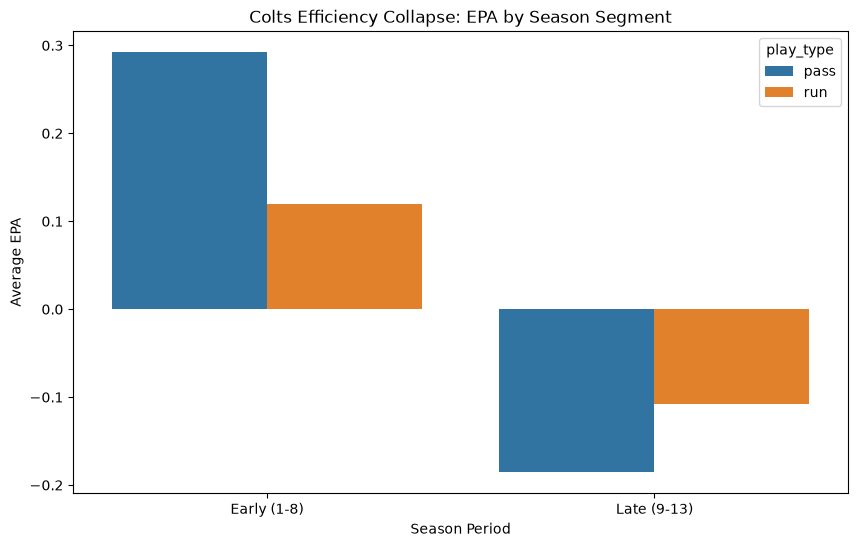

In [6]:
import nfl_data_py as nfl
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
pbp_data = nfl.import_pbp_data([2025])
pbp_data['season_segment'] = pbp_data['week'].apply(lambda x: 'Early (1-8)' if x <= 8 else 'Late (9-13)')

# 2. Process Data
colts_comparison = pbp_data[
    (pbp_data['posteam'] == 'IND') & 
    (pbp_data['season'] == 2025) & 
    (pbp_data['down'].isin([1])) & 
    (pbp_data['play_type'].isin(['run', 'pass']))
].groupby(['season_segment', 'play_type']).agg({
    'play_id': 'count',
    'epa': 'mean'
}).rename(columns={'play_id': 'total_plays', 'epa': 'avg_epa'}).reset_index()

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(
    data=colts_comparison, 
    x="season_segment", 
    y="avg_epa", 
    hue="play_type"
)

plt.title("Colts Efficiency Collapse: EPA by Season Segment")
plt.ylabel("Average EPA")
plt.xlabel("Season Period")
plt.show()

In [7]:
query_2nd = """
SELECT 
    CASE WHEN week <= 8 THEN 'Early (1-8)' ELSE 'Late (9-13)' END as season_segment,
    CAST(SUM(CASE WHEN play_type = 'run' THEN 1 ELSE 0 END) AS FLOAT) / 
    NULLIF(SUM(CASE WHEN play_type = 'pass' THEN 1 ELSE 0 END), 0) as run_to_pass_ratio
FROM pbp_data 
WHERE posteam = 'IND' AND season = 2025 AND down = 2 AND play_type IN ('run', 'pass')
GROUP BY season_segment
"""
df_2nd = pd.read_sql_query(query_2nd, conn)
print("--- 2nd Down Run/Pass Ratios ---")
print(df_2nd)

--- 2nd Down Run/Pass Ratios ---
  season_segment  run_to_pass_ratio
0    Early (1-8)           0.765432
1    Late (9-13)           0.620690


In [8]:

query = """
SELECT 
    CASE WHEN week <= 8 THEN 'Early (1-8)' ELSE 'Late (9-13)' END as season_segment,
    play_type, 
    COUNT(*) as total_plays, 
    AVG(epa) as avg_epa, 
    AVG(yards_gained) as avg_yards 
FROM pbp_data 
WHERE posteam = 'IND' 
  AND season = 2025 
  AND down IN (2) 
  AND play_type IN ('run', 'pass') 
GROUP BY season_segment, play_type
ORDER BY season_segment, play_type
"""

df_colts_split = pd.read_sql_query(query, conn)
print("Colts 2nd Down Run Pass Ratio: Early Weeks vs. Rest of Season")
print(df_colts_split)

Colts 2nd Down Run Pass Ratio: Early Weeks vs. Rest of Season
  season_segment play_type  total_plays   avg_epa  avg_yards
0    Early (1-8)      pass           81  0.186299   5.790123
1    Early (1-8)       run           62  0.211304   4.596774
2    Late (9-13)      pass          116 -0.083222   5.517241
3    Late (9-13)       run           72  0.079817   5.027778


2025 done.
Downcasting floats.


C:\Users\camer\AppData\Local\Temp\ipykernel_37644\4161827230.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pbp_data['season_segment'] = pbp_data['week'].apply(lambda x: 'Early (1-8)' if x <= 8 else 'Late (9-13)')


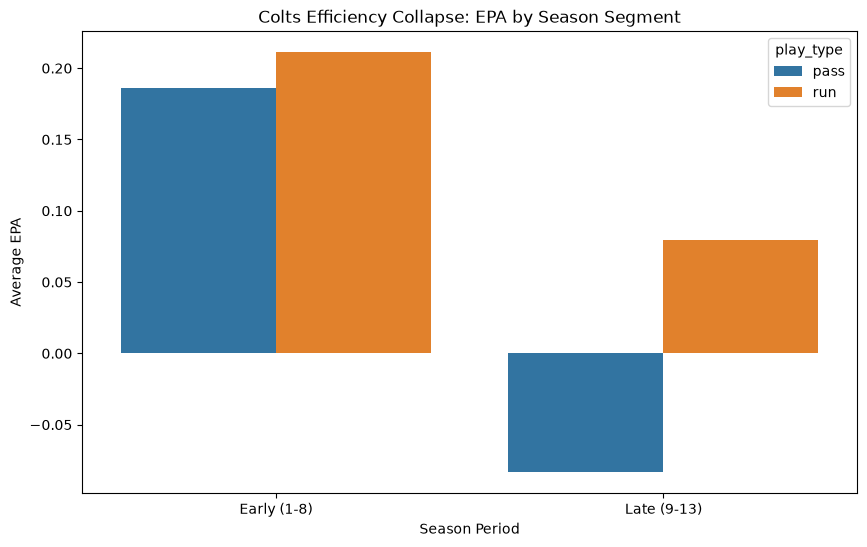

In [9]:

# 1. Load Data
pbp_data = nfl.import_pbp_data([2025])
pbp_data['season_segment'] = pbp_data['week'].apply(lambda x: 'Early (1-8)' if x <= 8 else 'Late (9-13)')

# 2. Process Data
colts_comparison = pbp_data[
    (pbp_data['posteam'] == 'IND') & 
    (pbp_data['season'] == 2025) & 
    (pbp_data['down'].isin([2])) & 
    (pbp_data['play_type'].isin(['run', 'pass']))
].groupby(['season_segment', 'play_type']).agg({
    'play_id': 'count',
    'epa': 'mean'
}).rename(columns={'play_id': 'total_plays', 'epa': 'avg_epa'}).reset_index()

# 3. Visualize
plt.figure(figsize=(10, 6))
sns.barplot(
    data=colts_comparison, 
    x="season_segment", 
    y="avg_epa", 
    hue="play_type"
)

plt.title("Colts Efficiency Collapse: EPA by Season Segment")
plt.ylabel("Average EPA")
plt.xlabel("Season Period")
plt.show()

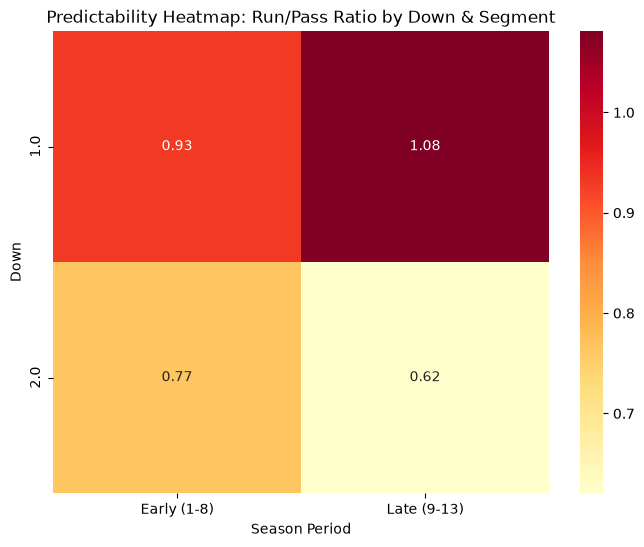

In [10]:


# 1. Filter and Aggregate: Calculate counts of run/pass for each down and segment
heatmap_data = pbp_data[
    (pbp_data['posteam'] == 'IND') & 
    (pbp_data['season'] == 2025) & 
    (pbp_data['down'].isin([1, 2])) & 
    (pbp_data['play_type'].isin(['run', 'pass']))
].groupby(['season_segment', 'down', 'play_type']).size().unstack(fill_value=0)

# 2. Calculate the Ratio
# (This acts like a SQL calculation: CASE WHEN...)
heatmap_data['ratio'] = heatmap_data['run'] / heatmap_data['pass']

# 3. Pivot for Heatmap format
# Rows: Down | Columns: Season Segment
heatmap_pivot = heatmap_data.reset_index().pivot(index='down', columns='season_segment', values='ratio')

# 4. Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_pivot, 
    annot=True, 
    cmap="YlOrRd", # Yellow to Red (Red = higher predictability/higher run ratio)
    fmt=".2f"
)

plt.title("Predictability Heatmap: Run/Pass Ratio by Down & Segment")
plt.ylabel("Down")
plt.xlabel("Season Period")
plt.show()

In [11]:
# Query for "Manageable" 2nd Downs (1-6 yards to go)
query_manageable = """
SELECT 
    CASE WHEN week <= 8 THEN 'Early (1-8)' ELSE 'Late (9-13)' END as season_segment,
    play_type,
    COUNT(*) as total_plays,
    AVG(epa) as avg_epa
FROM pbp_data 
WHERE posteam = 'IND' 
  AND season = 2025 
  AND down = 2 
  AND ydstogo <= 6
  AND play_type IN ('run', 'pass')
GROUP BY season_segment, play_type
"""

df_manageable = pd.read_sql_query(query_manageable, conn)
print(df_manageable)

  season_segment play_type  total_plays   avg_epa
0    Early (1-8)      pass           16  0.106199
1    Early (1-8)       run           45  0.312252
2    Late (9-13)      pass           30 -0.179705
3    Late (9-13)       run           50  0.138975


In [12]:


# 1. Define Success Logic based on your "4-yard" rule
# We add this column directly to your pbp_data
pbp_data['is_success'] = (
    ((pbp_data['down'] == 1) & (pbp_data['yards_gained'] >= 4)) |
    ((pbp_data['down'] == 2) & (pbp_data['yards_gained'] >= (pbp_data['ydstogo'] / 2)))
).astype(int)

# 2. Groupby for the "Forensic" table
# We group by segment and play_type, then aggregate success rate and EPA
forensic_table = pbp_data[
    (pbp_data['posteam'] == 'IND') & 
    (pbp_data['season'] == 2025) & 
    (pbp_data['down'].isin([1, 2])) & 
    (pbp_data['play_type'].isin(['run', 'pass']))
].groupby(['season_segment', 'play_type']).agg(
    total_plays=('play_type', 'size'),
    success_rate_pct=('is_success', lambda x: x.mean() * 100),
    avg_epa=('epa', 'mean')
).reset_index()

print(forensic_table)

  season_segment play_type  total_plays  success_rate_pct   avg_epa
0    Early (1-8)      pass          196         60.204082  0.248581
1    Early (1-8)       run          169         55.029586  0.153409
2    Late (9-13)      pass          227         46.696035 -0.133096
3    Late (9-13)       run          192         50.520833 -0.037713


C:\Users\camer\AppData\Local\Temp\ipykernel_37644\2227653607.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  pbp_data['is_success'] = (


In [13]:


# 1. Define segments and filter for the 1-13 regular season window
# This ensures no "future" data (post-week 13 or post-season) leaks into your calculation
pbp_1_13 = pbp_data[
    (pbp_data['season'] == 2025) & 
    (pbp_data['season_type'] == 'REG') & 
    (pbp_data['week'] <= 13)
].copy()

# Create the segment label
pbp_1_13['segment'] = pd.cut(
    pbp_1_13['week'], 
    bins=[0, 8, 13], 
    labels=['Early (1-8)', 'Late (9-13)']
)

# 2. Calculate Defensive Strength for EACH segment independently
# We define "strength" as the average EPA allowed by that defense during that specific timeframe
def_strength_early = pbp_1_13[pbp_1_13['segment'] == 'Early (1-8)'].groupby('defteam')['epa'].mean().rename('opp_def_strength')
def_strength_late = pbp_1_13[pbp_1_13['segment'] == 'Late (9-13)'].groupby('defteam')['epa'].mean().rename('opp_def_strength')

# Combine strengths into a mapping table
strength_map = pd.concat([def_strength_early, def_strength_late])

# 3. Analyze performance and merge with difficulty
# Grouping by week and team ensures the result is chronologically ordered
df_final = pbp_1_13[pbp_1_13['posteam'] == 'IND'].copy()
df_final = df_final.merge(strength_map, on='defteam', how='left')

comparison_table = df_final.groupby(['segment', 'week', 'defteam']).agg(
    colts_vs_them=('epa', 'mean'),
    opp_strength=('opp_def_strength', 'mean')
).sort_index(level=['segment', 'week'])

print(comparison_table)

                          colts_vs_them  opp_strength
segment     week defteam                             
Early (1-8) 1    MIA           0.251387      0.045084
            2    DEN           0.155293     -0.052225
            3    TEN           0.266243      0.048793
            4    LA           -0.063891     -0.074305
            5    LV            0.242410      0.009166
            6    ARI           0.166566      0.027992
            7    LAC           0.372199     -0.043899
            8    TEN           0.296975      0.048793
Late (9-13) 9    PIT          -0.041573      0.018146
            10   ATL           0.104444      0.020964
            12   KC            0.013101      0.058511
            13   HOU          -0.052534     -0.107708


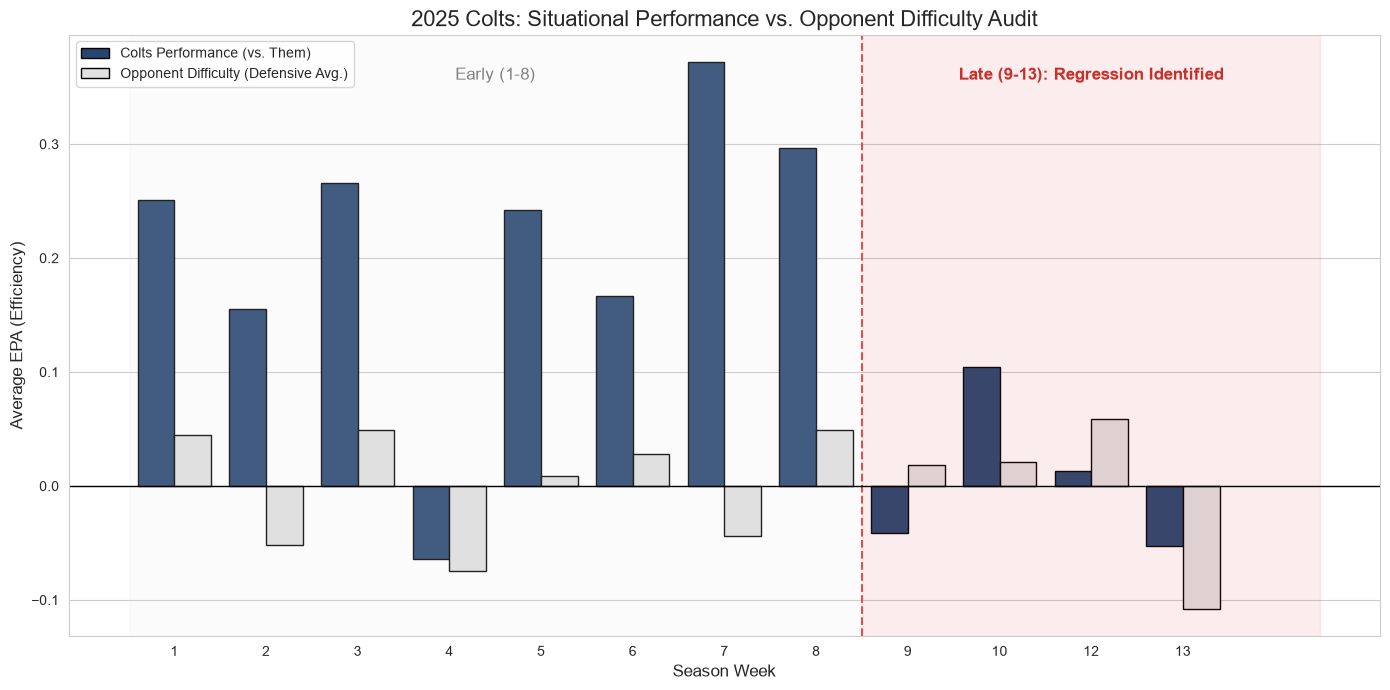

In [14]:


# 1. Setup and Style
# Bar charts benefit from a horizontal grid for easier level comparison.
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
plt.title('2025 Colts: Situational Performance vs. Opponent Difficulty Audit', fontsize=16)

# 2. Data Preparation
# Crucial step: Reset index so 'week' and 'segment' are columns, not index levels.
viz_df = comparison_table.reset_index()

# Sort by week to ensure chronological order.
viz_df = viz_df.sort_values('week')

# Melt the dataframe into long format. This allows Seaborn to easily plot grouped bars.
# It transforms the two EPA columns into one 'EPA' column and one 'Metric Type' label.
viz_melted = viz_df.melt(
    id_vars=['week', 'segment', 'defteam'],
    value_vars=['colts_vs_them', 'opp_strength'],
    var_name='Metric Type',
    value_name='EPA'
)

# Rename the metrics to be human-readable in the legend.
viz_melted['Metric Type'] = viz_melted['Metric Type'].map({
    'colts_vs_them': 'Colts Performance (vs. Them)',
    'opp_strength': 'Opponent Difficulty (Defensive Avg.)'
})

# 3. Plotting the Bars
# Grouped bar chart with clean, distinct colors.
# Note: 'dodge=True' is the default but crucial for grouping.
sns.barplot(
    data=viz_melted,
    x='week',
    y='EPA',
    hue='Metric Type',
    palette=['#1a437c', '#e0e0e0'], # Direct comparison: bold blue vs. muted gray
    edgecolor='black',
    linewidth=1
)

# 4. Context & Analysis Annotation
# Add the vertical dashed line at Week 8.
plt.axvline(x=7.5, color='#d9534f', linestyle='--', linewidth=1.5)

# Add shading and labels to define the two segments.
plt.axvspan(7.5, 12.5, color='#d9534f', alpha=0.10) # Shade Late segment light red
plt.axvspan(-0.5, 7.5, color='#e6e6e6', alpha=0.15) # Optional grey background for 'Early'

# Centered labels within each region.
plt.text(3.5, plt.gca().get_ylim()[1] * 0.9, 'Early (1-8)', fontsize=12, horizontalalignment='center', color='gray')
plt.text(10, plt.gca().get_ylim()[1] * 0.9, 'Late (9-13): Regression Identified', fontsize=12, horizontalalignment='center', fontweight='bold', color='#c9302c')

# 5. Fine-Tuning the Axes
plt.xlabel('Season Week', fontsize=12)
plt.ylabel('Average EPA (Efficiency)', fontsize=12)

# Centering the zero line (which represents league average)
plt.axhline(0, color='black', linewidth=1)

# Ensure the legend is informative but unobtrusive.
plt.legend(frameon=True, fontsize=10, loc='best')
plt.tight_layout()

plt.show()

In [15]:
# 1. Filter for Colts runs, 1st & 2nd down
df_runs = pbp_data[
    (pbp_data['posteam'] == 'IND') & 
    (pbp_data['play_type'] == 'run') & 
    (pbp_data['down'].isin([1, 2]))
].copy()

# 2. Categorize using run_location (Much more reliable data coverage)
# 'middle' is almost always 'Inside'. 'left'/'right' can be Inside/Outside.
# A common analyst approach is treating 'middle' as Inside, and 'left/right' as Outside.
df_runs['gap_type'] = df_runs['run_location'].apply(lambda x: 'Inside' if x == 'middle' else 'Outside')

# 3. Aggregate
gap_analysis = df_runs.groupby(['season_segment', 'gap_type']).agg({
    'play_id': 'count',
    'epa': 'mean'
}).rename(columns={'play_id': 'total_plays', 'epa': 'avg_epa'})

print(gap_analysis)

                         total_plays   avg_epa
season_segment gap_type                       
Early (1-8)    Inside             60  0.059429
               Outside           109  0.205141
Late (9-13)    Inside             80  0.046331
               Outside           112 -0.097743


In [16]:
# Calculate Success Rate: A positive EPA play is "successful"
df_success = pbp_data[
    (pbp_data['posteam'] == 'IND') & 
    (pbp_data['down'] == 1)
].copy()

df_success['is_success'] = (df_success['epa'] > 0).astype(int)

# Group by Segment to see if the "Success" of their strategy actually changed
success_analysis = df_success.groupby('season_segment')['is_success'].mean()
print(success_analysis)

season_segment
Early (1-8)    0.487395
Late (9-13)    0.378049
Name: is_success, dtype: float64
